# Data Collection
## Clean Finance Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
import statsmodels.api as sm

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (10, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
FINANCIAL_PANEL_FILE = OUTPUT_DIR + "financial_returns_and_controls.parquet"
FINANCIAL_PANEL_CSV = OUTPUT_DIR + "financial_returns_and_controls.csv"

# Analysis window
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"


## 1. Load Raw Data

In [2]:
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

# Basic cleaning: parse dates and sort
if "Date_" in df_raw.columns:
    df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
    df_raw = df_raw.sort_values("Date_").set_index("Date_")
else:
    # Adjust here if your date column has a different name
    raise KeyError("Expected a 'Date_' column. Please adjust the code to your date column name.")

print(df_raw.head())
print(df_raw.info())

            Close_BTC-USD  Close_CL=F  Close_CNY=X  Close_EUR=X  Close_GC=F  \
Date_                                                                         
2024-11-18            NaN         NaN          NaN          NaN         NaN   
2024-11-19     92343.7891     69.3900       7.2354       0.9438   2627.1001   
2024-11-20     94339.4922     68.8700       7.2381       0.9427   2648.2000   
2024-11-21     98504.7266     70.1000       7.2440       0.9482   2672.1001   
2024-11-22     98997.6641     71.2400       7.2337       0.9552   2709.8999   

            Close_^GSPC  Close_^TNX  High_BTC-USD  High_CL=F  High_CNY=X  ...  \
Date_                                                                     ...   
2024-11-18          NaN      4.4140           NaN        NaN         NaN  ...   
2024-11-19    5916.9800      4.3790    94002.8672    69.6900      7.2428  ...   
2024-11-20    5917.1099      4.4060    94902.0234    70.1500      7.2461  ...   
2024-11-21    5948.7100      4.4320    99

## 2. Rename columns

In [3]:
# Inspect available columns
df_raw.columns

Index(['Close_BTC-USD', 'Close_CL=F', 'Close_CNY=X', 'Close_EUR=X',
       'Close_GC=F', 'Close_^GSPC', 'Close_^TNX', 'High_BTC-USD', 'High_CL=F',
       'High_CNY=X', 'High_EUR=X', 'High_GC=F', 'High_^GSPC', 'High_^TNX',
       'Low_BTC-USD', 'Low_CL=F', 'Low_CNY=X', 'Low_EUR=X', 'Low_GC=F',
       'Low_^GSPC', 'Low_^TNX', 'Open_BTC-USD', 'Open_CL=F', 'Open_CNY=X',
       'Open_EUR=X', 'Open_GC=F', 'Open_^GSPC', 'Open_^TNX', 'Volume_BTC-USD',
       'Volume_CL=F', 'Volume_CNY=X', 'Volume_EUR=X', 'Volume_GC=F',
       'Volume_^GSPC', 'Volume_^TNX'],
      dtype='object')

In [4]:
# Define a renaming map
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Open_BTC-USD": "open_btc",
    "High_BTC-USD": "high_btc",
    "Low_BTC-USD": "low_btc",
    "Volume_BTC-USD": "vol_btc",

    "Close_GC=F": "close_gold",
    "Open_GC=F": "open_gold",
    "High_GC=F": "high_gold",
    "Low_GC=F": "low_gold",
    "Volume_GC=F": "vol_gold",

    "Close_CL=F": "close_oil",
    "Open_CL=F": "open_oil",
    "High_CL=F": "high_oil",
    "Low_CL=F": "low_oil",
    "Volume_CL=F": "vol_oil",

    "Close_^GSPC": "close_spx",
    "Open_^GSPC": "open_spx",
    "High_^GSPC": "high_spx",
    "Low_^GSPC": "low_spx",
    "Volume_^GSPC": "vol_spx",

    "Close_CNY=X": "close_usdcny",
    "Open_CNY=X": "open_usdcny",
    "High_CNY=X": "high_usdcny",
    "Low_CNY=X": "low_usdcny",
    "Volume_CNY=X": "vol_usdcny",

    "Close_EUR=X": "close_eurusd",
    "Open_EUR=X": "open_eurusd",
    "High_EUR=X": "high_eurusd",
    "Low_EUR=X": "low_eurusd",
    "Volume_EUR=X": "vol_eurusd",

    "Close_^TNX": "close_ust10y",
    "Open_^TNX": "open_ust10y",
    "High_^TNX": "high_ust10y",
    "Low_^TNX": "low_ust10y",
    "Volume_^TNX": "vol_ust10y",
}

df = df_raw.rename(columns=rename_map)

print("After renaming:")
print(df.head())

After renaming:
            close_btc  close_oil  close_usdcny  close_eurusd  close_gold  \
Date_                                                                      
2024-11-18        NaN        NaN           NaN           NaN         NaN   
2024-11-19 92343.7891    69.3900        7.2354        0.9438   2627.1001   
2024-11-20 94339.4922    68.8700        7.2381        0.9427   2648.2000   
2024-11-21 98504.7266    70.1000        7.2440        0.9482   2672.1001   
2024-11-22 98997.6641    71.2400        7.2337        0.9552   2709.8999   

            close_spx  close_ust10y   high_btc  high_oil  high_usdcny  ...  \
Date_                                                                  ...   
2024-11-18        NaN        4.4140        NaN       NaN          NaN  ...   
2024-11-19  5916.9800        4.3790 94002.8672   69.6900       7.2428  ...   
2024-11-20  5917.1099        4.4060 94902.0234   70.1500       7.2461  ...   
2024-11-21  5948.7100        4.4320 99014.2188   70.3800     

## 3. Align frequencies and handle non-trading days

We keep the native trading-day calendar (no synthetic weekend/holiday rows). Prices are forward-filled within existing rows only, and a flag marks rows that needed filling.

In [5]:
# Create a continuous business-day index over the sample
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)

# Identify price and volume columns
price_cols = [c for c in df.columns if c.startswith(("close_", "open_", "high_", "low_"))]
volume_cols = [c for c in df.columns if c.startswith("vol_")]

# Track rows where prices were missing prior to forward-fill
missing_price_rows = df[price_cols].isna().any(axis=1)

# Forward-fill prices, leave volumes as-is
df[price_cols] = df[price_cols].ffill()

# Flag rows that relied on forward-filled prices
df["ffill_flag"] = missing_price_rows

print(df.head())

            close_btc  close_oil  close_usdcny  close_eurusd  close_gold  \
2024-11-18        NaN        NaN           NaN           NaN         NaN   
2024-11-19 92343.7891    69.3900        7.2354        0.9438   2627.1001   
2024-11-20 94339.4922    68.8700        7.2381        0.9427   2648.2000   
2024-11-21 98504.7266    70.1000        7.2440        0.9482   2672.1001   
2024-11-22 98997.6641    71.2400        7.2337        0.9552   2709.8999   

            close_spx  close_ust10y   high_btc  high_oil  high_usdcny  ...  \
2024-11-18        NaN        4.4140        NaN       NaN          NaN  ...   
2024-11-19  5916.9800        4.3790 94002.8672   69.6900       7.2428  ...   
2024-11-20  5917.1099        4.4060 94902.0234   70.1500       7.2461  ...   
2024-11-21  5948.7100        4.4320 99014.2188   70.3800       7.2459  ...   
2024-11-22  5969.3398        4.4100 99655.5000   71.5100       7.2487  ...   

            open_spx  open_ust10y           vol_btc     vol_oil  vol_usdcn


## 4. Construct returns and control variables

We compute:

- **Absolute log returns** (volatility proxies) for Bitcoin, Gold, S&P 500.
- **Log differences** for FX and oil.
- **First difference** for the 10-year yield.


In [6]:
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)

# Asset returns (absolute values for volatility prediction)
returns["r_btc"] = np.abs(log_return(df["close_btc"]))
returns["r_gold"] = np.abs(log_return(df["close_gold"]))
returns["r_spx"] = np.abs(log_return(df["close_spx"]))

# Signed returns for trading strategies
returns["r_btc_signed"] = log_return(df["close_btc"])
returns["r_gold_signed"] = log_return(df["close_gold"])
returns["r_spx_signed"] = log_return(df["close_spx"])

# Control variables
returns["dln_eurusd"] = log_return(df["close_eurusd"])   # USD/EUR
returns["dln_usdcny"] = log_return(df["close_usdcny"])   # USD/CNY
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

# Drop initial NaNs from differencing
returns = returns.dropna()

# Restrict to analysis window
returns = returns.loc[START_DATE:END_DATE]

# Compute momentum indicators (1-day, 3-day, 5-day)
for asset in ["btc", "gold", "spx"]:
    signed_col = f"r_{asset}_signed"
    returns[f"momentum_1d_{asset}"] = returns[signed_col].rolling(1).mean()
    returns[f"momentum_3d_{asset}"] = returns[signed_col].rolling(3).mean()
    returns[f"momentum_5d_{asset}"] = returns[signed_col].rolling(5).mean()

# Drop NaNs created by rolling windows
returns = returns.dropna()

print(f"Returns shape: {returns.shape}")
print(f"Columns: {list(returns.columns)}")
returns.head()


Returns shape: (104, 19)
Columns: ['r_btc', 'r_gold', 'r_spx', 'r_btc_signed', 'r_gold_signed', 'r_spx_signed', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'momentum_1d_btc', 'momentum_3d_btc', 'momentum_5d_btc', 'momentum_1d_gold', 'momentum_3d_gold', 'momentum_5d_gold', 'momentum_1d_spx', 'momentum_3d_spx', 'momentum_5d_spx']


,r_btc,r_gold,r_spx,r_btc_signed,r_gold_signed,r_spx_signed,dln_eurusd,dln_usdcny,dln_oil,dy10,momentum_1d_btc,momentum_3d_btc,momentum_5d_btc,momentum_1d_gold,momentum_3d_gold,momentum_5d_gold,momentum_1d_spx,momentum_3d_spx,momentum_5d_spx
2025-01-07,0.0518,0.0069,0.0112,-0.0518,0.0069,-0.0112,-0.0078,0.0004,0.0093,0.0650,-0.0518,0.0001,0.0073,0.0069,-0.0003,0.0021,-0.0112,0.0023,0.0009
2025-01-08,0.0196,0.0029,0.0016,-0.0196,0.0029,0.0016,0.0039,0.0006,-0.0126,0.0100,-0.0196,-0.0106,0.0013,0.0029,0.0024,0.0027,0.0016,-0.0014,0.0012
2025-01-09,0.0273,0.0072,0.0000,-0.0273,0.0072,0.0000,0.0030,0.0007,0.0081,0.0000,-0.0273,-0.0329,-0.0093,0.0072,0.0057,0.0019,0.0000,-0.0032,0.0017
2025-01-10,0.0237,0.0092,0.0155,0.0237,0.0092,-0.0155,0.0017,0.0001,0.0352,0.0830,0.0237,-0.0077,-0.0071,0.0092,0.0064,0.0047,-0.0155,-0.0047,-0.0039
2025-01-13,0.0020,0.0130,0.0016,-0.0020,-0.0130,0.0016,0.0052,-0.0001,0.0290,0.0270,-0.0020,-0.0019,-0.0154,-0.0130,0.0011,0.0026,0.0016,-0.0047,-0.0047



## 5. Exploratory data analysis

Time-series plots, summary statistics, and correlations.


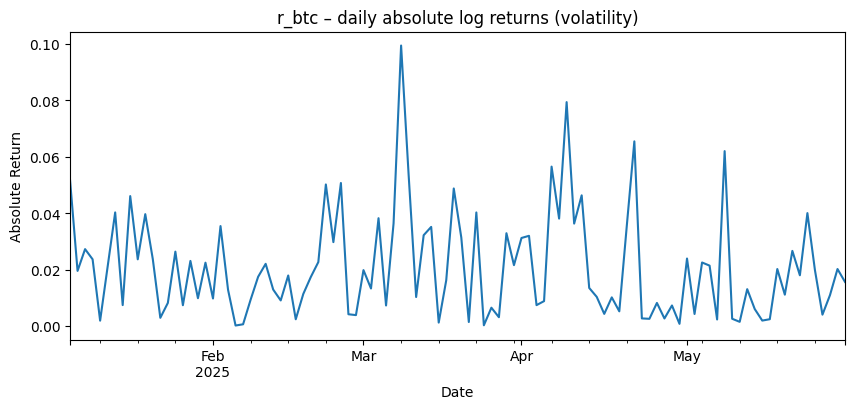

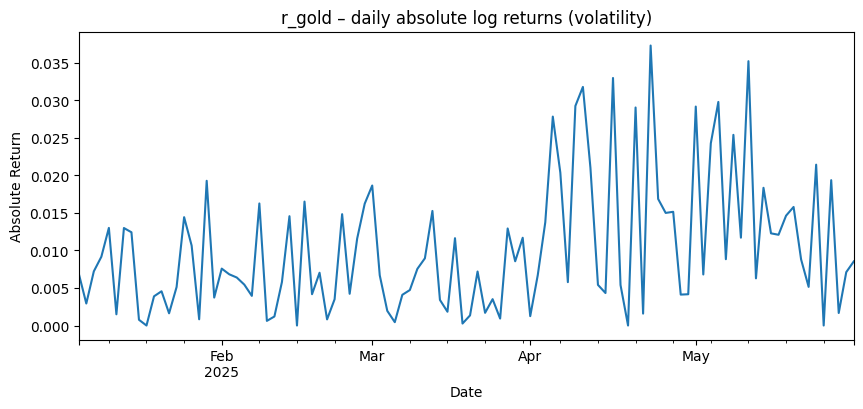

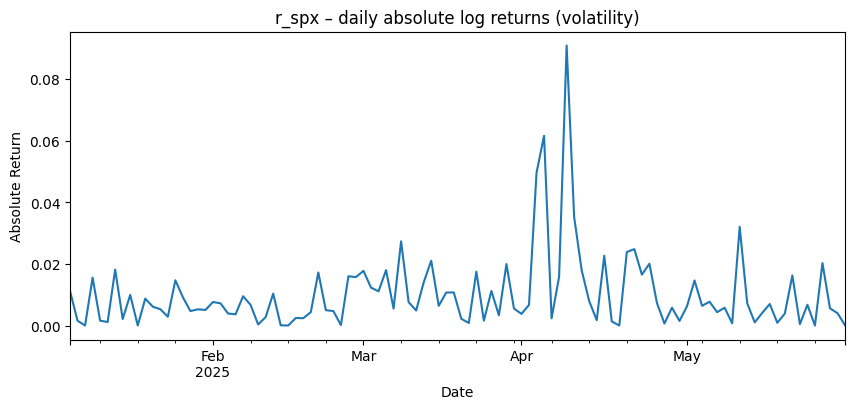

In [7]:
# Plot returns
for col in ["r_btc", "r_gold", "r_spx"]:
    ax = returns[col].plot(title=f"{col} – daily absolute log returns (volatility)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Absolute Return")
    plt.show()

In [8]:
# Summary statistics
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
r_btc,104.0000,0.0209,0.0187,0.0002,0.0071,0.0175,0.0316,0.0994
r_gold,104.0000,0.0102,0.0090,0.0000,0.0039,0.0072,0.0149,0.0373
r_spx,104.0000,0.0101,0.0128,0.0000,0.0024,0.0063,0.0146,0.0909
r_btc_signed,104.0000,0.0002,0.0281,-0.0994,-0.0176,-0.0003,0.0145,0.0794
r_gold_signed,104.0000,0.0021,0.0135,-0.0373,-0.0042,0.0032,0.0090,0.0330
r_spx_signed,104.0000,-0.0001,0.0163,-0.0616,-0.0058,0.0007,0.0063,0.0909
dln_eurusd,104.0000,-0.0010,0.0063,-0.0275,-0.0045,0.0003,0.0026,0.0145
dln_usdcny,104.0000,-0.0002,0.0026,-0.0113,-0.0003,0.0000,0.0007,0.0123
dln_oil,104.0000,-0.0018,0.0202,-0.0770,-0.0156,0.0000,0.0094,0.0454
dy10,104.0000,-0.0019,0.0611,-0.1410,-0.0430,0.0000,0.0345,0.1700


In [9]:
# Correlation matrix
corr = returns[["r_btc", "r_gold", "r_spx"]].corr()
corr

,r_btc,r_gold,r_spx
r_btc,1.0000,-0.0226,0.3067
r_gold,-0.0226,1.0000,0.4345
r_spx,0.3067,0.4345,1.0000



## 6. Stationarity checks (ADF tests)


In [10]:
def adf_test(series, name=""):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF Test for {name}")
    print(f"  Test statistic: {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.4f}")
    print("  Critical values:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    print("-" * 40)

for col in returns.columns:
    adf_test(returns[col], name=col)

ADF Test for r_btc
  Test statistic: -8.4476
  p-value:        0.0000
  Critical values:
    1%: -3.4955
    5%: -2.8900
    10%: -2.5820
----------------------------------------
ADF Test for r_gold
  Test statistic: -1.8773
  p-value:        0.3428
  Critical values:
    1%: -3.5035
    5%: -2.8935
    10%: -2.5838
----------------------------------------
ADF Test for r_spx
  Test statistic: -3.0090
  p-value:        0.0341
  Critical values:
    1%: -3.4975
    5%: -2.8909
    10%: -2.5824
----------------------------------------
ADF Test for r_btc_signed
  Test statistic: -11.2532
  p-value:        0.0000
  Critical values:
    1%: -3.4955
    5%: -2.8900
    10%: -2.5820
----------------------------------------
ADF Test for r_gold_signed
  Test statistic: -9.9703
  p-value:        0.0000
  Critical values:
    1%: -3.4955
    5%: -2.8900
    10%: -2.5820
----------------------------------------
ADF Test for r_spx_signed
  Test statistic: -11.2015
  p-value:        0.0000
  Critical

## 7. Export dataset
We export a panel containing the returns and control variables for reuse in the emotion/EPI notebook.

In [11]:
panel = returns.copy()

# Optionally include event dummies or other flags
# panel = returns_events

panel.to_parquet(FINANCIAL_PANEL_FILE)
panel.to_csv(FINANCIAL_PANEL_CSV)

print("Saved financial panel to:")
print("  ", FINANCIAL_PANEL_FILE)
print("  ", FINANCIAL_PANEL_CSV)

Saved financial panel to:
   ./data/financial_returns_and_controls.parquet
   ./data/financial_returns_and_controls.csv
